In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import quad, quad_vec
from scipy.sparse.linalg import eigsh # computing smallest and largest eigenvalues
from scipy.interpolate import AAA
import csv

import algo


In [2]:
a = 0.5

d0 = 1000
k0 = int(a*d0)
v0 = np.mean(np.sort(np.random.randn(10000, k0)), axis=0)
W0 = np.random.randn(k0,d0)
Z0 = np.random.randn(d0,d0)
Z0 = (Z0+Z0.T)/np.sqrt(2*d0)
S0 = W0.T@np.diag(v0)@W0/k0

def supp(t):
    Y0 = S0 + np.sqrt(t)*Z0
    eigmin = eigsh(Y0, k=1, which='SA', return_eigenvectors=False)[0]
    eigmax = eigsh(Y0, k=1, which='LA', return_eigenvectors=False)[0]
    return eigmin, eigmax

def R(s): 
    func = lambda x: a*x/(a-s*x)*np.exp(-x**2/2)
    return quad_vec(func, -10, 10)[0]/np.sqrt(2*np.pi)

samples = np.linspace(-3, 3, 21) - 1e-6*1j
R_approx = AAA(samples, R(samples))

def stieltjes(x, t):
    def eq(g):
        g = g[0] + 1j*g[1]
        eq = R_approx(-g) - t*g - 1/g - x
        return [eq.real, eq.imag]
    eps = 1e-4
    init = [-eps, eps] if x>=0 else [eps, eps]
    sol = fsolve(eq, init)
    return sol[0] + abs(sol[1])*1j

def f_RIE(R, t):
    if t<1e-6:
        return R
    h = lambda x: -stieltjes(x-1e-6j, t).real
    eigval, eigvec = np.linalg.eigh(R)
    eigval_denoised = np.array([e - 2*t*h(e) for e in eigval])
    return eigvec@np.diag(eigval_denoised)@eigvec.T

def F_RIE(t):
    xmin, xmax = supp(t)
    rho = lambda x: stieltjes(x, t).imag/np.pi
    return t - 4*np.pi**2/3 * t**2 * quad(lambda x: rho(x)**3, xmin, xmax)[0]

### RIE

In [3]:
t = 2

d = 1000
k = int(a*d)
v = np.random.randn(k)
W = np.random.randn(k,d)
Z = np.random.randn(d,d)
Z = (Z+Z.T)/np.sqrt(2*d)
S = W.T@np.diag(v)@W/k
Y = S + np.sqrt(t)*Z

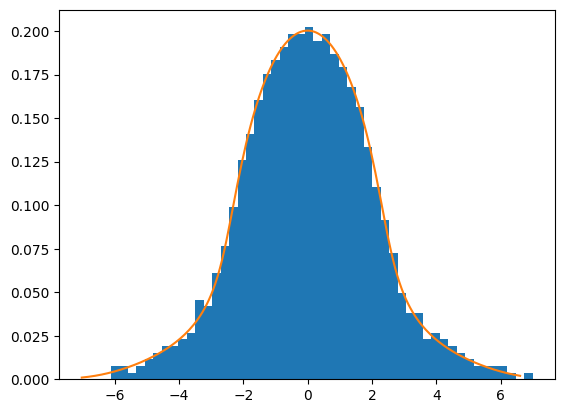

In [4]:
xmin, xmax = supp(t)
rho = lambda x: stieltjes(x, t).imag/np.pi
xs = np.linspace(xmin, xmax, 201)
rhos = [rho(x) for x in xs]

eigvals = np.linalg.eigvalsh(Y)
plt.hist(eigvals, density=1, bins = 50)

plt.plot(xs, rhos)
plt.show()

In [5]:
S_hat = f_RIE(Y, t)
np.sum((S-S_hat)**2)/d, F_RIE(t)

(np.float64(0.6973840217384396), 0.6868010787534584)

### GAMP-RIE

In [9]:
d = 200
gamma = a 
Delta = 0.1
k = int(gamma*d)

sig = lambda x: np.maximum(x,0)
# sig = lambda x: np.tanh(2*x)
# sig = lambda x: np.where(x > 0, x, (np.exp(x) - 1))

vlaw = 'gauss'
prior = 'gauss'


alpha = 6
%time algo.algo_perf(d, gamma, alpha, Delta, f_RIE, F_RIE, sig, vlaw, prior)


CPU times: user 2min 26s, sys: 1min 32s, total: 3min 59s
Wall time: 21.2 s


np.float64(0.017367619044436306)

In [8]:
import sys
import os
folder = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, folder)
import theory2

theory2.quantities(sig, alpha, gamma, Delta, vlaw, prior, details=False)['mmse_uni']

np.float64(0.021386819805703578)

In [10]:
d = 150
gamma = a 
Delta = 0.1
k = int(gamma*d)

sig = lambda x: np.maximum(x,0)
# sig = lambda x: np.tanh(2*x)
# sig = lambda x: np.where(x > 0, x, (np.exp(x) - 1))

vlaw = 'gauss'
prior = 'gauss'


alphas = [0.375, 1.375, 2.375, 3.375, 4.375, 5.375, 6.375]

with open(f'relu_{vlaw}.csv', 'a', newline='') as file:
    writer = csv.writer(file)
    for i in range(9):
        mmses = [algo.algo_perf(d, gamma, alpha, Delta, f_RIE, F_RIE, sig, vlaw, prior) for alpha in alphas]
        writer.writerow(mmses)
        file.flush()

